## Portfolio Analysis

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis_toolkit as at

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Loading the data
ffme = at.get_ffme_returns()
ffme.head()

,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
1926-07,NaN,-0.0043,0.0152,0.0268,-0.0057,0.0059,0.0160,0.0147,0.0333,-0.0145,0.0029,-0.0015,0.0133,0.0124,0.0198,0.0155,0.0138,0.0338,0.0329
1926-08,NaN,0.0390,0.0304,0.0209,0.0384,0.0359,0.0371,0.0161,0.0233,0.0512,0.0259,0.0403,0.0315,0.0272,0.0472,0.0160,0.0163,0.0098,0.0370
1926-09,NaN,-0.0108,-0.0054,0.0016,-0.0048,-0.0140,0.0000,-0.0050,-0.0009,0.0093,-0.0187,-0.0227,-0.0053,0.0007,-0.0007,-0.0164,0.0064,-0.0086,0.0067
1926-10,NaN,-0.0332,-0.0352,-0.0306,-0.0329,-0.0410,-0.0289,-0.0336,-0.0295,-0.0484,-0.0177,-0.0336,-0.0483,-0.0298,-0.0280,-0.0345,-0.0327,-0.0347,-0.0243
1926-11,NaN,-0.0046,0.0382,0.0309,-0.0055,0.0218,0.0341,0.0339,0.0316,-0.0078,-0.0032,-0.0029,0.0465,0.0324,0.0357,0.0382,0.0295,0.0361,0.0270


In [3]:
# Validating the index type of the dataset
ffme.index

PeriodIndex(['1926-07', '1926-08', '1926-09', '1926-10', '1926-11', '1926-12',
             '1927-01', '1927-02', '1927-03', '1927-04',
             ...
             '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08',
             '2018-09', '2018-10', '2018-11', '2018-12'],
            dtype='period[M]', length=1110)

In [4]:
# Selecting Top and Bottom Deciles by Market Capitalization
rets = ffme[['Lo 10', 'Hi 10']]
rets.columns = ['Small Cap', 'Large Cap']
rets.head()

,Small Cap,Large Cap
1926-07,-0.0145,0.0329
1926-08,0.0512,0.0370
1926-09,0.0093,0.0067
1926-10,-0.0484,-0.0243
1926-11,-0.0078,0.0270


<Axes: >

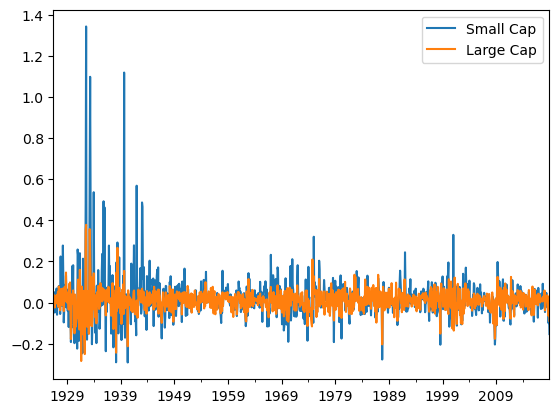

In [5]:
# Plotting the returns across time
rets.plot.line()

## Computing Drawdown

### Large Cap

In [6]:
# Calculates the percentage drawdown across time
drawdown = at.drawdown(rets['Large Cap'])
drawdown.head()

,Wealth,Cumulative Peaks,Percentage Drawdown
1926-07,1032.900000,1032.900000,0.0000
1926-08,1071.117300,1071.117300,0.0000
1926-09,1078.293786,1078.293786,0.0000
1926-10,1052.091247,1078.293786,-0.0243
1926-11,1080.497711,1080.497711,0.0000


<Axes: >

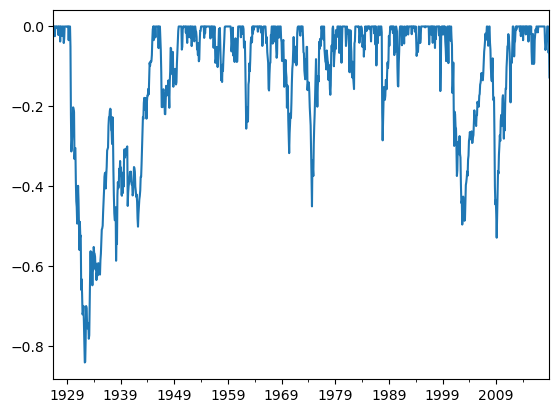

In [7]:
# Plotting percentage drawdown across time
drawdown['Percentage Drawdown'].plot.line()

In [8]:
# Highest drawdown since 2008 and the respective month
highest_drawdown = drawdown['2008':]['Percentage Drawdown'].min() * 100
highest_drawdown_month = drawdown['2008':]['Percentage Drawdown'].idxmin()
print(f'The highest drawdown since 2008 was {highest_drawdown:.2f}% and it was on {highest_drawdown_month}.')

The highest drawdown since 2008 was -52.81% and it was on 2009-02.


### Small Cap

In [9]:
# Calculates the percentage drawdown across time
drawdown = at.drawdown(rets['Small Cap'])
drawdown.head()

,Wealth,Cumulative Peaks,Percentage Drawdown
1926-07,985.500000,985.500000,0.000000
1926-08,1035.957600,1035.957600,0.000000
1926-09,1045.592006,1045.592006,0.000000
1926-10,994.985353,1045.592006,-0.048400
1926-11,987.224467,1045.592006,-0.055822


<Axes: >

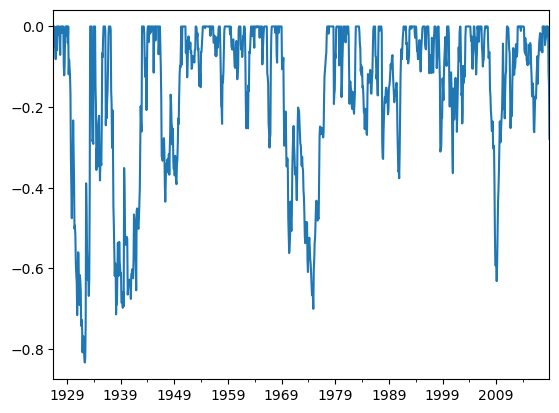

In [10]:
# Plotting percentage drawdown across time
drawdown['Percentage Drawdown'].plot.line()

In [11]:
# Highest drawdown since 2008 and the respective month
highest_drawdown = drawdown['2008':]['Percentage Drawdown'].min() * 100
highest_drawdown_month = drawdown['2008':]['Percentage Drawdown'].idxmin()
print(f'The highest drawdown since 2008 was {highest_drawdown:.2f}% and it was on {highest_drawdown_month}.')

The highest drawdown since 2008 was -63.12% and it was on 2009-02.


The graphs illustrate that equities with smaller market capitalization are more volatile, and hence, riskier. In times of market downturns, such equities tend to experience larger drawdowns.

## Deviations from Normality

In [12]:
# Loading in data
hfi = at.get_hfi_returns()
hfi.head()

,Convertible Arbitrage,CTA Global,Distressed Securities,Emerging Markets,Equity Market Neutral,Event Driven,Fixed Income Arbitrage,Global Macro,Long/Short Equity,Merger Arbitrage,Relative Value,Short Selling,Funds Of Funds
date,,,,,,,,,,,,,
1997-01,0.0119,0.0393,0.0178,0.0791,0.0189,0.0213,0.0191,0.0573,0.0281,0.0150,0.0180,-0.0166,0.0317
1997-02,0.0123,0.0298,0.0122,0.0525,0.0101,0.0084,0.0122,0.0175,-0.0006,0.0034,0.0118,0.0426,0.0106
1997-03,0.0078,-0.0021,-0.0012,-0.0120,0.0016,-0.0023,0.0109,-0.0119,-0.0084,0.0060,0.0010,0.0778,-0.0077
1997-04,0.0086,-0.0170,0.0030,0.0119,0.0119,-0.0005,0.0130,0.0172,0.0084,-0.0001,0.0122,-0.0129,0.0009
1997-05,0.0156,-0.0015,0.0233,0.0315,0.0189,0.0346,0.0118,0.0108,0.0394,0.0197,0.0173,-0.0737,0.0275


In [13]:
# Validating the index type of the dataset
hfi.index

PeriodIndex(['1997-01', '1997-02', '1997-03', '1997-04', '1997-05', '1997-06',
             '1997-07', '1997-08', '1997-09', '1997-10',
             ...
             '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07',
             '2018-08', '2018-09', '2018-10', '2018-11'],
            dtype='period[M]', name='date', length=263)

### Skewness

In [14]:
# Mean < median means negatively skewed
# Mean > median means positively skewed
hfi_skew = pd.concat([hfi.mean(), hfi.median(), hfi.mean() > hfi.median()], axis=1)
hfi_skew.columns = ['Mean', 'Median', 'Positive Skew?']
hfi_skew

,Mean,Median,Positive Skew?
Convertible Arbitrage,0.005508,0.0065,False
CTA Global,0.004074,0.0014,True
Distressed Securities,0.006946,0.0089,False
Emerging Markets,0.006253,0.0096,False
Equity Market Neutral,0.004498,0.0051,False
Event Driven,0.006344,0.0084,False
Fixed Income Arbitrage,0.004365,0.0055,False
Global Macro,0.005403,0.0038,True
Long/Short Equity,0.006331,0.0079,False
Merger Arbitrage,0.005356,0.0060,False


In [15]:
# Calculates the skewness and sorts in ascending order
at.skewness(hfi).sort_values()

Fixed Income Arbitrage   -3.940320
Convertible Arbitrage    -2.639592
Equity Market Neutral    -2.124435
Relative Value           -1.815470
Event Driven             -1.409154
Merger Arbitrage         -1.320083
Distressed Securities    -1.300842
Emerging Markets         -1.167067
Long/Short Equity        -0.390227
Funds Of Funds           -0.361783
CTA Global                0.173699
Short Selling             0.767975
Global Macro              0.982922
dtype: float64

### Kurtosis

In [16]:
# Platykurtic - less kurtosis than a normal distribution
# Leptokurtic - more kurtosis than a normal distribution
# Mesokurtic - same kurtosis as a normal distribution
at.kurtosis(hfi).sort_values()

CTA Global                 2.952960
Long/Short Equity          4.523893
Global Macro               5.741679
Short Selling              6.117772
Funds Of Funds             7.070153
Distressed Securities      7.889983
Event Driven               8.035828
Merger Arbitrage           8.738950
Emerging Markets           9.250788
Relative Value            12.121208
Equity Market Neutral     17.218555
Convertible Arbitrage     23.280834
Fixed Income Arbitrage    29.842199
dtype: float64

### Jarque-Bera Test for Normality

In [17]:
# Significance level by default is 1%
at.is_normal(hfi)

Convertible Arbitrage     False
CTA Global                 True
Distressed Securities     False
Emerging Markets          False
Equity Market Neutral     False
Event Driven              False
Fixed Income Arbitrage    False
Global Macro              False
Long/Short Equity         False
Merger Arbitrage          False
Relative Value            False
Short Selling             False
Funds Of Funds            False
dtype: bool

### Testing the Fama-French dataset for Normality

In [18]:
at.skewness(rets).sort_values()

Large Cap    0.233445
Small Cap    4.410739
dtype: float64

In [19]:
at.kurtosis(rets).sort_values()

Large Cap    10.694654
Small Cap    46.845008
dtype: float64

In [20]:
at.is_normal(rets)

Small Cap    False
Large Cap    False
dtype: bool

## Downside Measures

### Semi-Deviation

In [21]:
# Calculates only negative standard deviation
at.semi_deviation(hfi).sort_values()

Global Macro              0.006579
Merger Arbitrage          0.008875
Equity Market Neutral     0.009566
Funds Of Funds            0.012122
Relative Value            0.012244
CTA Global                0.012443
Long/Short Equity         0.014051
Distressed Securities     0.015185
Event Driven              0.015429
Fixed Income Arbitrage    0.017763
Convertible Arbitrage     0.019540
Short Selling             0.027283
Emerging Markets          0.028039
dtype: float64

### VaR and CVaR

The sign is inverted to present the loss i.e., positive numbers are used.

In [22]:
# Historic VaR at the 1% level
at.var_historic(hfi, level=1).sort_values()

Equity Market Neutral     0.018000
Global Macro              0.024316
Merger Arbitrage          0.025336
Relative Value            0.026660
Convertible Arbitrage     0.031776
Funds Of Funds            0.039664
Fixed Income Arbitrage    0.041672
Distressed Securities     0.046654
Event Driven              0.048612
CTA Global                0.049542
Long/Short Equity         0.049558
Emerging Markets          0.088466
Short Selling             0.113576
dtype: float64

In [23]:
# Conditional VaR (Expected Shortfall) at the 1% level
at.cvar_historic(hfi, level=1).sort_values()

Global Macro              0.029333
Equity Market Neutral     0.036100
Merger Arbitrage          0.036233
Relative Value            0.052367
CTA Global                0.054767
Funds Of Funds            0.061133
Long/Short Equity         0.061867
Distressed Securities     0.070967
Event Driven              0.071267
Fixed Income Arbitrage    0.072467
Convertible Arbitrage     0.086100
Short Selling             0.123867
Emerging Markets          0.141167
dtype: float64

In [24]:
at.cvar_historic(rets)

Small Cap    0.162609
Large Cap    0.121277
dtype: float64

In [25]:
# Parametric Gaussian VaR
at.var_gaussian(hfi, level=1).sort_values()

Equity Market Neutral     0.014380
Merger Arbitrage          0.016978
Relative Value            0.020873
Fixed Income Arbitrage    0.022428
Global Macro              0.028780
Funds Of Funds            0.031880
Event Driven              0.032533
Distressed Securities     0.032623
Convertible Arbitrage     0.032960
Long/Short Equity         0.039956
CTA Global                0.050107
Emerging Markets          0.069296
Short Selling             0.112563
dtype: float64

In [26]:
# Cornish-Fisher modification
at.var_gaussian(hfi, level=1, modified=True).sort_values()

Global Macro              0.022236
Merger Arbitrage          0.032882
Equity Market Neutral     0.040248
Relative Value            0.046398
CTA Global                0.046612
Funds Of Funds            0.050031
Long/Short Equity         0.051614
Event Driven              0.057035
Distressed Securities     0.057506
Fixed Income Arbitrage    0.060776
Convertible Arbitrage     0.100100
Short Selling             0.109810
Emerging Markets          0.127977
dtype: float64

<Axes: title={'center': 'Hedge Fund Indices: VaR at 5%'}>

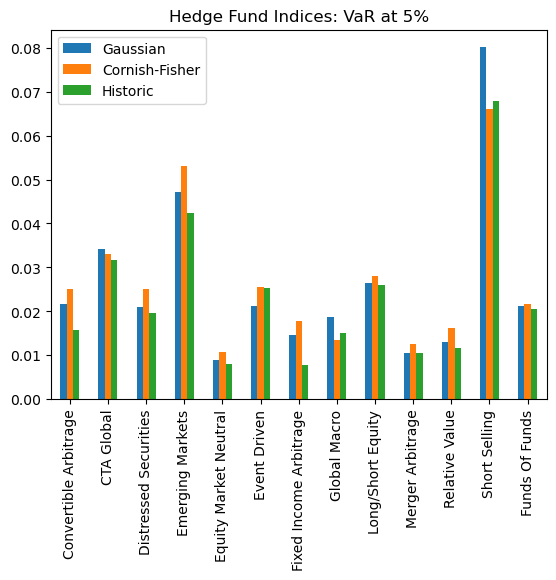

In [27]:
# Comparing the different VaRs at the default level (5%)
var_table = [at.var_gaussian(hfi), at.var_gaussian(hfi, modified=True), at.var_historic(hfi)]
comparison = pd.concat(var_table, axis=1)
comparison.columns=['Gaussian', 'Cornish-Fisher', 'Historic']
comparison.plot.bar(title="Hedge Fund Indices: VaR at 5%")

In some cases, the Cornish-Fisher VaR is lower i.e., estimates a smaller loss than you would get from a pure Gaussian assumption. This can happen if the observed skewness is positive, as is the case for "Short Selling" and "Global Macro".

In [28]:
at.skewness(hfi).sort_values(ascending=False)

Global Macro              0.982922
Short Selling             0.767975
CTA Global                0.173699
Funds Of Funds           -0.361783
Long/Short Equity        -0.390227
Emerging Markets         -1.167067
Distressed Securities    -1.300842
Merger Arbitrage         -1.320083
Event Driven             -1.409154
Relative Value           -1.815470
Equity Market Neutral    -2.124435
Convertible Arbitrage    -2.639592
Fixed Income Arbitrage   -3.940320
dtype: float64

In [29]:
at.kurtosis(hfi).sort_values(ascending=False)

Fixed Income Arbitrage    29.842199
Convertible Arbitrage     23.280834
Equity Market Neutral     17.218555
Relative Value            12.121208
Emerging Markets           9.250788
Merger Arbitrage           8.738950
Event Driven               8.035828
Distressed Securities      7.889983
Funds Of Funds             7.070153
Short Selling              6.117772
Global Macro               5.741679
Long/Short Equity          4.523893
CTA Global                 2.952960
dtype: float64

## Efficient Frontier

In [30]:
# Loading in data
ind = at.get_ind_returns()
ind.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
1926-07,0.0056,-0.0519,0.0129,0.0293,0.1097,-0.0048,0.0808,0.0177,0.0814,0.0039,...,0.0083,0.0922,0.0206,0.0770,0.0193,-0.2379,0.0007,0.0187,0.0037,0.0520
1926-08,0.0259,0.2703,0.0650,0.0055,0.1001,-0.0358,-0.0251,0.0425,0.0550,0.0814,...,0.0217,0.0202,0.0439,-0.0238,0.0488,0.0539,-0.0075,-0.0013,0.0446,0.0676
1926-09,0.0116,0.0402,0.0126,0.0658,-0.0099,0.0073,-0.0051,0.0069,0.0533,0.0231,...,0.0241,0.0225,0.0019,-0.0554,0.0005,-0.0787,0.0025,-0.0056,-0.0123,-0.0386
1926-10,-0.0306,-0.0331,0.0106,-0.0476,0.0947,-0.0468,0.0012,-0.0057,-0.0476,0.0100,...,-0.0011,-0.0200,-0.0109,-0.0508,-0.0264,-0.1538,-0.0220,-0.0411,-0.0516,-0.0849
1926-11,0.0635,0.0729,0.0455,0.0166,-0.0580,-0.0054,0.0187,0.0542,0.0520,0.0311,...,0.0163,0.0377,0.0364,0.0384,0.0160,0.0467,0.0652,0.0433,0.0224,0.0400


In [31]:
# Calculating Sharpe ratios for every industry
at.sharpe_ratio(ind, 0.03, 12).sort_values()

Coal     0.084275
Steel    0.126052
Whlsl    0.143494
Other    0.160862
Mines    0.177109
Books    0.192686
Games    0.194420
Txtls    0.194906
Trans    0.214624
Autos    0.227548
Cnstr    0.229351
FabPr    0.265297
Servs    0.267263
Fin      0.282243
Carry    0.285916
ElcEq    0.293063
Clths    0.293105
Util     0.306945
Hshld    0.307349
Oil      0.330358
Meals    0.332717
BusEq    0.342974
Chems    0.344903
Beer     0.351780
Rtail    0.364325
Paper    0.364722
Telcm    0.383294
Hlth     0.437783
Smoke    0.446361
Food     0.454770
dtype: float64

<Axes: title={'center': 'Industry Sharpe Ratios 1926-2018'}>

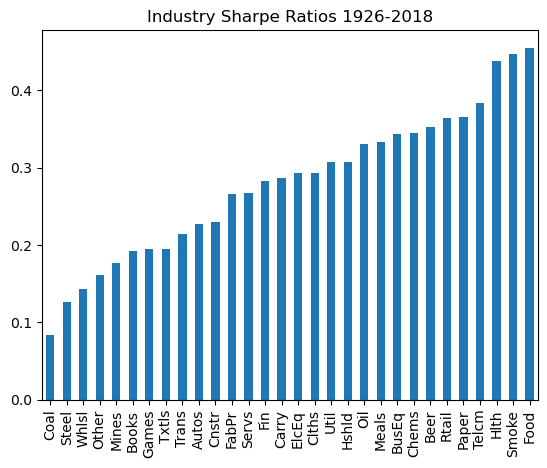

In [32]:
# Plotting Sharpe ratios
at.sharpe_ratio(ind, 0.03, 12).sort_values().plot.bar(title='Industry Sharpe Ratios 1926-2018')

<Axes: title={'center': 'Industry Sharpe Ratios since 2000'}>

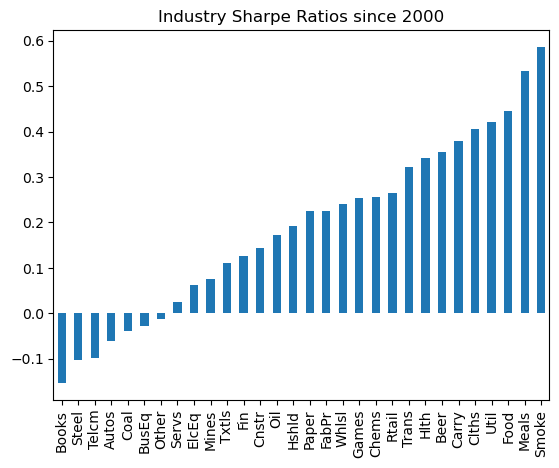

In [33]:
at.sharpe_ratio(ind["2000":], 0.03, 12).sort_values().plot.bar(title='Industry Sharpe Ratios since 2000')

### Expected Returns

In [34]:
# Annualized returns for every industry
at.annualize_rets(ind, 12).sort_values()

Coal     0.062543
Whlsl    0.067420
Steel    0.067926
Other    0.068767
Mines    0.075994
Books    0.079147
Txtls    0.083356
Trans    0.084093
Cnstr    0.086209
Util     0.090147
Games    0.091829
Telcm    0.092669
Hshld    0.093513
Clths    0.093518
Autos    0.094397
FabPr    0.098153
Fin      0.098169
Oil      0.101700
Paper    0.106115
Meals    0.106644
Food     0.106649
Carry    0.107120
Chems    0.107320
Rtail    0.107438
ElcEq    0.109179
Servs    0.109196
BusEq    0.112490
Hlth     0.116723
Beer     0.120041
Smoke    0.122324
dtype: float64

<Axes: title={'center': 'Industry Annualized Returns 1926-2018'}>

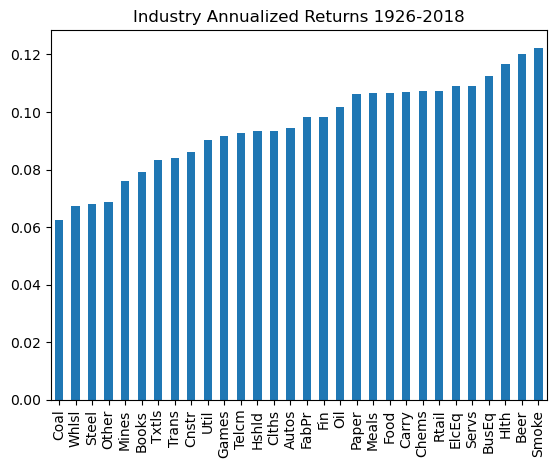

In [35]:
# Plotting annualized returns
at.annualize_rets(ind, 12).sort_values().plot.bar(title='Industry Annualized Returns 1926-2018')

### Covariance Matrix

In [36]:
# Covariance matrix for every industry
# Diagonals are variances
ind.cov()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Food,0.002241,0.002383,0.001831,0.002971,0.002473,0.002191,0.001855,0.002042,0.002189,0.002463,...,0.001418,0.001634,0.002013,0.002104,0.002363,0.002388,0.002262,0.002233,0.002571,0.002301
Beer,0.002383,0.005164,0.001902,0.004127,0.003071,0.002744,0.002237,0.002554,0.002775,0.003369,...,0.001674,0.002051,0.002583,0.002599,0.003094,0.003486,0.002781,0.002943,0.003263,0.003036
Smoke,0.001831,0.001902,0.003374,0.002519,0.001994,0.001848,0.001536,0.001807,0.001823,0.001989,...,0.001225,0.001406,0.001707,0.001812,0.001968,0.002046,0.001814,0.001835,0.002146,0.002060
Games,0.002971,0.004127,0.002519,0.007951,0.004682,0.003662,0.003400,0.003352,0.004056,0.005092,...,0.002555,0.003238,0.004349,0.003689,0.004702,0.004909,0.004030,0.004282,0.004828,0.004594
Books,0.002473,0.003071,0.001994,0.004682,0.005119,0.002954,0.002981,0.002626,0.003195,0.004176,...,0.002051,0.002885,0.003169,0.003136,0.003861,0.003778,0.003255,0.003271,0.003794,0.003526
Hshld,0.002191,0.002744,0.001848,0.003662,0.002954,0.003365,0.002108,0.002404,0.002672,0.002972,...,0.001595,0.001978,0.002652,0.002596,0.002804,0.002907,0.002654,0.002587,0.003003,0.002895
Clths,0.001855,0.002237,0.001536,0.003400,0.002981,0.002108,0.003701,0.001864,0.002510,0.003426,...,0.001480,0.002241,0.002489,0.002435,0.002835,0.002897,0.002694,0.002664,0.002727,0.002715
Hlth,0.002042,0.002554,0.001807,0.003352,0.002626,0.002404,0.001864,0.003095,0.002439,0.002579,...,0.001543,0.001940,0.002553,0.002339,0.002562,0.002698,0.002396,0.002396,0.002832,0.002572
Chems,0.002189,0.002775,0.001823,0.004056,0.003195,0.002672,0.002510,0.002439,0.003961,0.003580,...,0.001894,0.002144,0.003105,0.003161,0.003418,0.003139,0.002820,0.002734,0.003401,0.003209
Txtls,0.002463,0.003369,0.001989,0.005092,0.004176,0.002972,0.003426,0.002579,0.003580,0.005896,...,0.002045,0.002529,0.003308,0.003343,0.004117,0.004028,0.003453,0.003394,0.003928,0.003794


In [37]:
# Expected returns and covariance matrix from 1996 to 2000
er = at.annualize_rets(ind['1996':'2000'], 12)
cov = ind['1996':'2000'].cov()

In [38]:
# Subset of data
l = ['Food', 'Beer', 'Smoke', 'Coal']

In [39]:
er[l]

Food     0.116799
Beer     0.141126
Smoke    0.107830
Coal     0.414689
dtype: float64

In [40]:
cov.loc[l, l]

,Food,Beer,Smoke,Coal
Food,0.002609,0.002379,0.002061,0.000027
Beer,0.002379,0.005264,0.001359,0.001728
Smoke,0.002061,0.001359,0.008349,-0.000733
Coal,0.000027,0.001728,-0.000733,0.018641


### Two Asset Frontier

<Axes: xlabel='Volatility'>

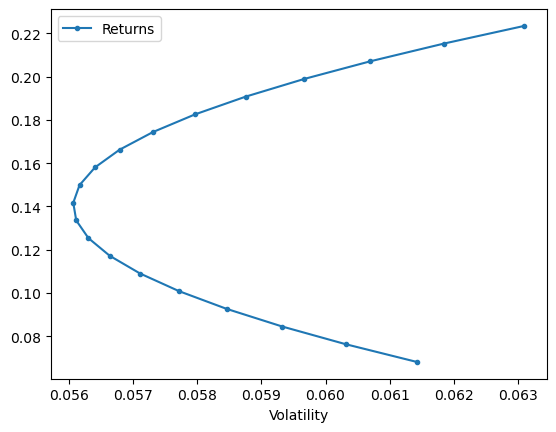

In [41]:
# Plotting the two asset frontier
m = ['Games', 'Fin']
at.plot_ef2(20, er[m], cov.loc[m, m])

### Multi Asset Frontier

<Axes: xlabel='Volatility'>

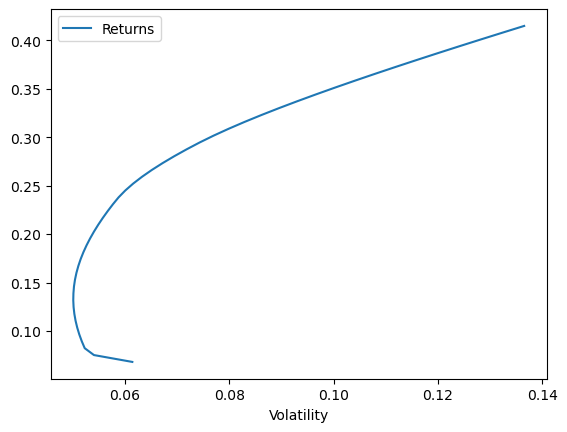

In [42]:
# Plotting the multi asset frontier
n = ['Smoke', 'Fin', 'Games', 'Coal']
at.plot_ef(50, er[n], cov.loc[n, n])

### Maximum Sharpe Ratio (Tangency) Portfolio

<Axes: xlabel='Volatility'>

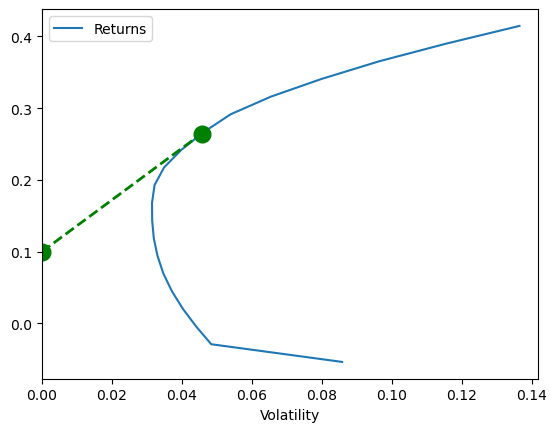

In [43]:
# Plotting the Capital Market Line and the Efficient Frontier
at.plot_ef(20, er, cov, style='-', show_cml=True, riskfree_rate=0.1)

### Equally Weighted Portfolio

<Axes: xlabel='Volatility'>

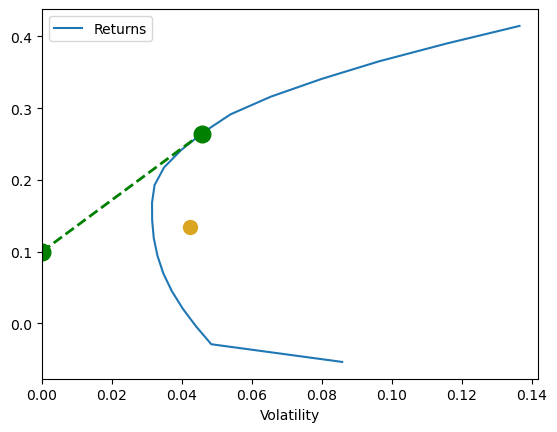

In [44]:
at.plot_ef(20, er, cov, style='-', show_cml=True, riskfree_rate=0.1, show_ew=True)

### Global Minimum Variance Portfolio

<Axes: xlabel='Volatility'>

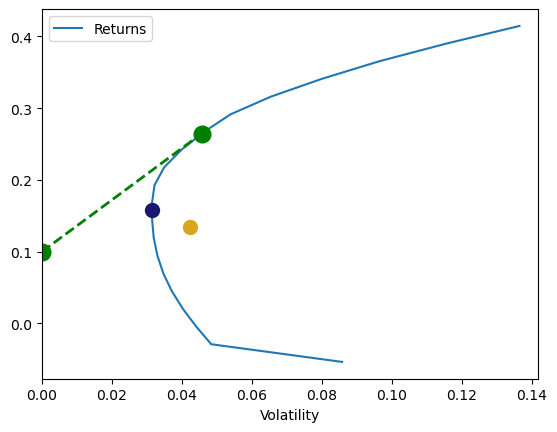

In [45]:
at.plot_ef(20, er, cov, style='-', show_cml=True, riskfree_rate=0.1, show_ew=True, show_gmv=True)